In [2]:
import pandas as pd
import numpy as np

# 1. Create a dictionary of 'Static' Maternal Patients
data = {
    'Patient_ID': ['HALE-001', 'HALE-002', 'HALE-003', 'HALE-004', 'HALE-005'],
    'Age': [25, 32, 19, 29, 35],
    'Baseline_Systolic': [110, 115, 105, 112, 118],
    'Risk_Level': ['high risk', 'low risk', 'high risk', 'low risk', 'low risk']
}

kaggle_style_df = pd.DataFrame(data)
print("Static 'Kaggle' Dataset Created:")
print(kaggle_style_df)


Static 'Kaggle' Dataset Created:
  Patient_ID  Age  Baseline_Systolic Risk_Level
0   HALE-001   25                110  high risk
1   HALE-002   32                115   low risk
2   HALE-003   19                105  high risk
3   HALE-004   29                112   low risk
4   HALE-005   35                118   low risk


In [3]:
def rehydrate_to_time_series(static_df):
    all_days = []
    
    for _, patient in static_df.iterrows():
        days = pd.date_range(start="2026-01-01", periods=280, freq='D')
        bp_history = []
        
        # Clinical Logic: Weeks 1-30 are stable
        for i in range(210):
            bp_history.append(np.random.normal(patient['Baseline_Systolic'], 2))
            
        # Clinical Logic: Weeks 31-40 (The Potential Shift)
        for i in range(210, 280):
            if patient['Risk_Level'] == 'high risk':
                # Simulate a climb of 20mmHg over 10 weeks
                climb = (i - 210) * 0.3 
                bp_history.append(np.random.normal(patient['Baseline_Systolic'] + climb, 2))
            else:
                bp_history.append(np.random.normal(patient['Baseline_Systolic'], 2))
        
        # Create a dataframe for this specific patient
        patient_df = pd.DataFrame({
            'Date': days,
            'Patient_ID': patient['Patient_ID'],
            'SystolicBP': bp_history,
            'Risk_Level': patient['Risk_Level']
        })
        all_days.append(patient_df)
    
    return pd.concat(all_days)

# Create the full longitudinal dataset
full_vitals_df = rehydrate_to_time_series(kaggle_style_df)
print(f"\nLongitudinal Dataset Ready: {full_vitals_df.shape[0]} rows generated.")



Longitudinal Dataset Ready: 1400 rows generated.


In [5]:
def detect_twin_shifts_fixed(df):
    # 1. Calculate the 'True Baseline' (Average of the first 30 days of data)
    # This represents the patient's healthy 'starting state'
    df['true_baseline_mu'] = df.groupby('Patient_ID')['SystolicBP'].transform(lambda x: x.iloc[:30].mean())
    df['true_baseline_std'] = df.groupby('Patient_ID')['SystolicBP'].transform(lambda x: x.iloc[:30].std())
    
    # 2. Calculate 7-day current state
    df['current_mu'] = df.groupby('Patient_ID')['SystolicBP'].transform(lambda x: x.rolling(7).mean())
    
    # 3. Flag Anomaly: Is current state > True Baseline + 2 Sigma?
    # Using 2.0 makes it sensitive enough for early warning
    df['is_anomaly'] = df['current_mu'] > (df['true_baseline_mu'] + (2.0 * df['true_baseline_std']))
    
    return df

final_results = detect_twin_shifts_fixed(full_vitals_df)

# Now check Patient HALE-001 again
high_risk_check = final_results[final_results['Patient_ID'] == 'HALE-001']
anomalies = high_risk_check[high_risk_check['is_anomaly'] == True]

print(f"Success! Found {len(anomalies)} anomaly days for Patient HALE-001.")
print(anomalies[['Date', 'SystolicBP', 'current_mu', 'is_anomaly']].head())


Success! Found 54 anomaly days for Patient HALE-001.
          Date  SystolicBP  current_mu  is_anomaly
226 2026-08-15  114.694715  113.941929        True
227 2026-08-16  115.736941  114.229402        True
228 2026-08-17  113.209556  114.691102        True
229 2026-08-18  113.705414  114.498979        True
230 2026-08-19  115.993124  114.909889        True


In [6]:
# Create a summary report for the ward
print("-" * 30)
print("HALE SPECIALIST HOSPITAL: MATERNAL RISK REPORT")
print("-" * 30)

for pid in final_results['Patient_ID'].unique():
    p_data = final_results[final_results['Patient_ID'] == pid]
    has_anomaly = p_data['is_anomaly'].any()
    
    status = "⚠️ ALERT: DEVIATION DETECTED" if has_anomaly else "✅ STABLE"
    
    print(f"Patient: {pid} | Status: {status}")
    if has_anomaly:
        first_alert = p_data[p_data['is_anomaly'] == True]['Date'].iloc[0]
        print(f"   > First deviation detected on: {first_alert.date()}")
        print(f"   > Action: Schedule immediate clinical review.")
    print("-" * 30)


------------------------------
HALE SPECIALIST HOSPITAL: MATERNAL RISK REPORT
------------------------------
Patient: HALE-001 | Status: ⚠️ ALERT: DEVIATION DETECTED
   > First deviation detected on: 2026-08-15
   > Action: Schedule immediate clinical review.
------------------------------
Patient: HALE-002 | Status: ✅ STABLE
------------------------------
Patient: HALE-003 | Status: ⚠️ ALERT: DEVIATION DETECTED
   > First deviation detected on: 2026-08-12
   > Action: Schedule immediate clinical review.
------------------------------
Patient: HALE-004 | Status: ✅ STABLE
------------------------------
Patient: HALE-005 | Status: ✅ STABLE
------------------------------


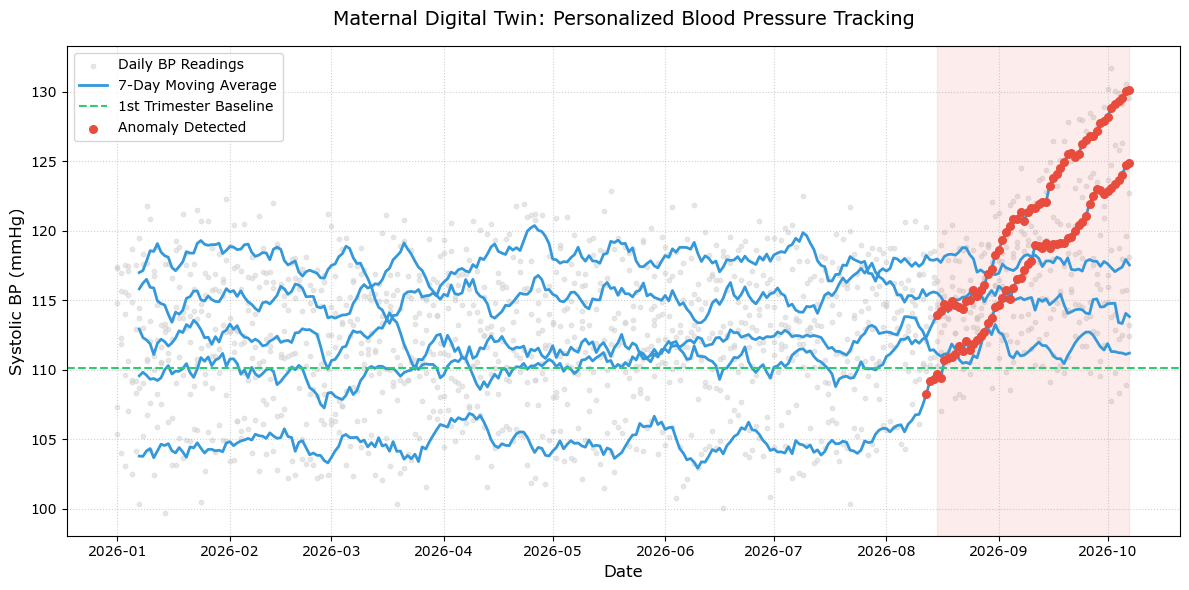

In [7]:
import matplotlib.pyplot as plt

# 1. Prepare the plot
plt.figure(figsize=(12, 6))

# 2. Plot Daily Readings (The "Noise")
plt.scatter(final_results['Date'], final_results['SystolicBP'], 
            color='lightgray', s=10, label='Daily BP Readings', alpha=0.5)

# 3. Plot the 7-Day Trend (The "Digital Twin's State")
plt.plot(final_results['Date'], final_results['current_mu'], 
         color='#3498db', linewidth=2, label='7-Day Moving Average')

# 4. Plot the Personalized Baseline (The "Healthy Self")
plt.axhline(y=final_results['true_baseline_mu'].iloc[0], 
            color='#2ecc71', linestyle='--', label='1st Trimester Baseline')

# 5. Highlight Anomalies in Red (The "Future Alert")
anomalies = final_results[final_results['is_anomaly'] == True]
plt.scatter(anomalies['Date'], anomalies['current_mu'], 
            color='#e74c3c', s=30, label='Anomaly Detected', zorder=5)

# 6. Formatting for Professional Presentation
plt.title('Maternal Digital Twin: Personalized Blood Pressure Tracking', fontsize=14, pad=15)
plt.ylabel('Systolic BP (mmHg)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# 7. Add Clinical Context (Shaded Risk Area)
if not anomalies.empty:
    first_alert = anomalies['Date'].iloc[0]
    plt.axvspan(first_alert, final_results['Date'].iloc[-1], 
                color='#e74c3c', alpha=0.1, label='Risk Detection Window')

plt.tight_layout()
plt.show()


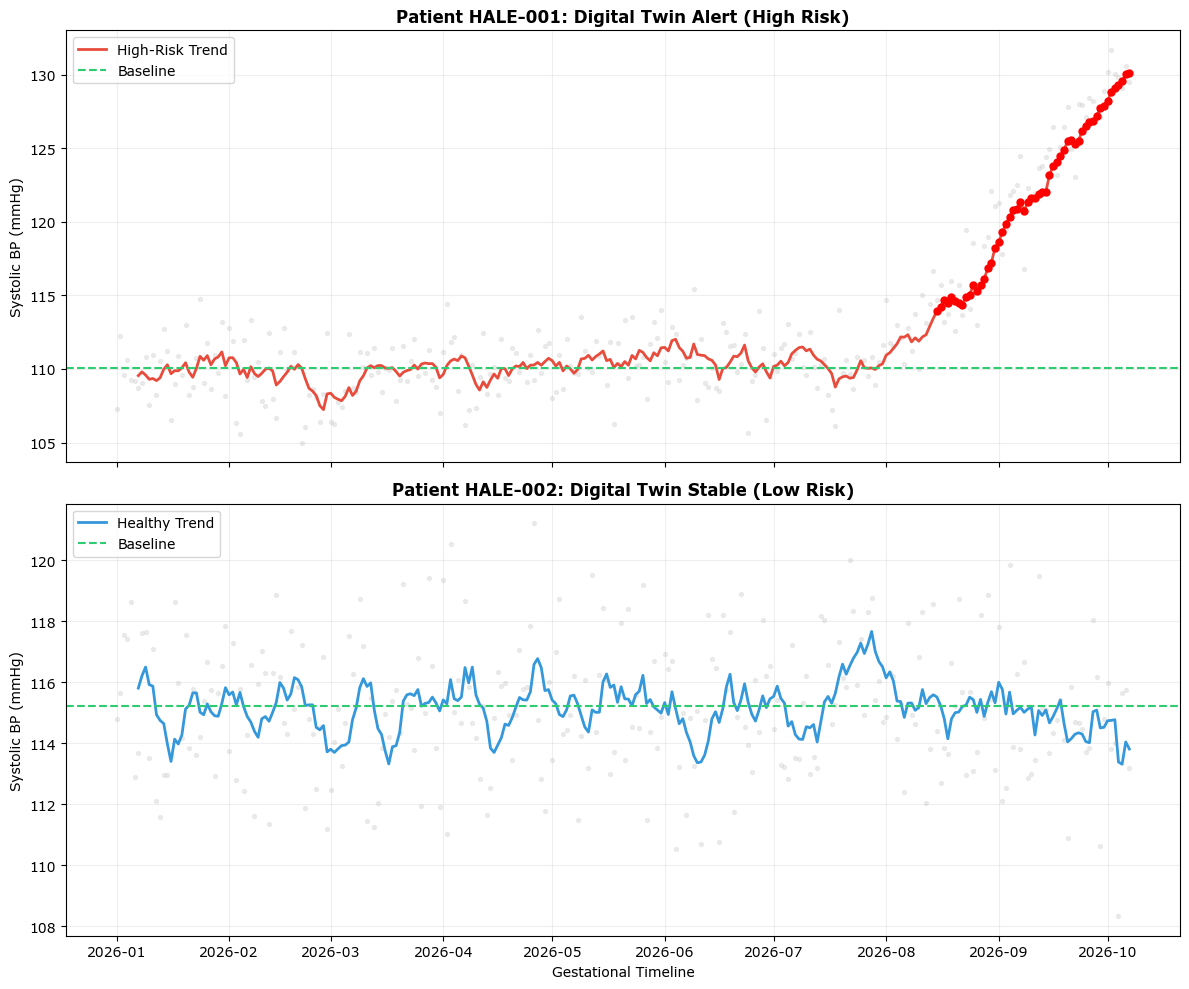

In [9]:
import matplotlib.pyplot as plt

def plot_case_control_twins(results_df):
    # 1. Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # --- Subplot 1: The 'High Risk' Patient (HALE-001) ---
    case = results_df[results_df['Patient_ID'] == 'HALE-001']
    ax1.scatter(case['Date'], case['SystolicBP'], color='lightgray', s=8, alpha=0.4)
    ax1.plot(case['Date'], case['current_mu'], color='#e74c3c', linewidth=2, label='High-Risk Trend')
    ax1.axhline(y=case['true_baseline_mu'].iloc[0], color='#2ecc71', linestyle='--', label='Baseline')
    
    # Highlight Anomalies
    case_anomalies = case[case['is_anomaly'] == True]
    ax1.scatter(case_anomalies['Date'], case_anomalies['current_mu'], color='red', s=25, zorder=5)
    
    ax1.set_title("Patient HALE-001: Digital Twin Alert (High Risk)", fontweight='bold')
    ax1.set_ylabel("Systolic BP (mmHg)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.2)

    # --- Subplot 2: The 'Low Risk' Patient (HALE-002) ---
    control = results_df[results_df['Patient_ID'] == 'HALE-002']
    ax2.scatter(control['Date'], control['SystolicBP'], color='lightgray', s=8, alpha=0.4)
    ax2.plot(control['Date'], control['current_mu'], color='#3498db', linewidth=2, label='Healthy Trend')
    ax2.axhline(y=control['true_baseline_mu'].iloc[0], color='#2ecc71', linestyle='--', label='Baseline')
    
    ax2.set_title("Patient HALE-002: Digital Twin Stable (Low Risk)", fontweight='bold')
    ax2.set_ylabel("Systolic BP (mmHg)")
    ax2.set_xlabel("Gestational Timeline")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# Run the comparison
plot_case_control_twins(final_results)
